# Блок 3. Анализ каналов продаж

**Вопрос:** различается ли ценность клиентов по типу использования каналов?

**Данные:** витрина hm.channels_mart (1 строка = 1 клиент)
**Типы:** offline-only, online-only, omnichannel (оба канала)

## Гипотеза (Г2 из EDA)
Omnichannel-клиенты ценнее single-channel по частоте, чеку и разнообразию.


In [1]:
import clickhouse_connect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

client = clickhouse_connect.get_client(
    host='localhost', port=8123,
    username='analyst', password='analyst', database='hm'
)

def q(sql): return client.query_df(sql)

Сравнение метрик по типам каналов

In [8]:
channel_stats = q("""
SELECT
    channel_type,
    count()                              AS customers,
    round(median(total_transactions), 1) AS median_transactions,
    round(median(total_spent), 3)        AS median_spent,
    round(median(unique_articles), 1)    AS median_articles,
    round(median(customer_lifespan_days), 0) AS median_lifespan_days,
    round(avg(total_transactions), 1)      AS avg_transactions,
    round(avg(total_spent), 3)             AS avg_spent,
    round(avg(unique_articles), 1)         AS avg_articles,
    round(avg(customer_lifespan_days), 0)  AS avg_lifespan_days
FROM hm.channels_mart
GROUP BY channel_type
ORDER BY median_spent DESC
""")
display(channel_stats)

,channel_type,customers,median_transactions,median_spent,median_articles,median_lifespan_days,avg_transactions,avg_spent,avg_articles,avg_lifespan_days
0,omnichannel,483255,29.0,0.730,26.0,564.0,45.0,1.240,38.8,496.0
1,online-only,625163,5.0,0.136,4.0,0.0,12.5,0.374,10.4,150.0
2,offline-only,253863,5.0,0.113,5.0,0.0,8.7,0.203,8.3,154.0


Сравнение при контроле на активность: только клиенты с >=2 покупками

In [7]:
channel_fair = q("""
SELECT
    channel_type,
    count()                                   AS customers,
    round(median(total_transactions), 1)      AS median_transactions,
    round(median(total_spent), 3)             AS median_spent,
    round(median(unique_articles), 1)         AS median_articles,
    round(median(customer_lifespan_days), 0)  AS median_lifespan_days,
    round(avg(total_transactions), 1)      AS avg_transactions,
    round(avg(total_spent), 3)             AS avg_spent,
    round(avg(unique_articles), 1)         AS avg_articles,
    round(avg(customer_lifespan_days), 0)  AS avg_lifespan_days
FROM hm.channels_mart
WHERE total_transactions >= 2
GROUP BY channel_type
ORDER BY median_spent DESC
""")
display(channel_fair)

,channel_type,customers,median_transactions,median_spent,median_articles,median_lifespan_days,avg_transactions,avg_spent,avg_articles,avg_lifespan_days
0,omnichannel,483255,29.0,0.742,26.0,565.0,45.0,1.240,38.8,496.0
1,online-only,528748,7.0,0.183,6.0,35.0,14.6,0.435,12.1,177.0
2,offline-only,218764,6.0,0.137,6.0,24.0,10.0,0.230,9.4,179.0


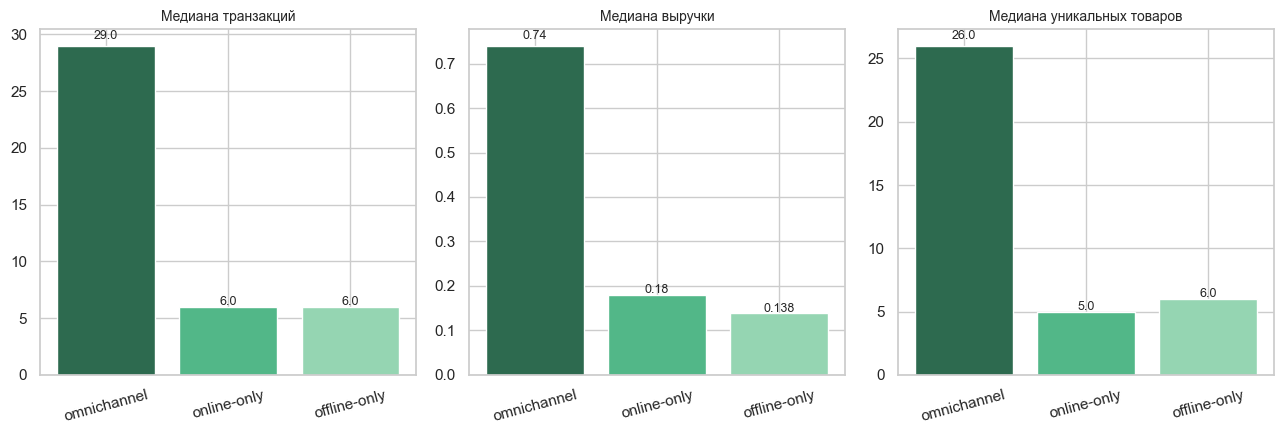

In [9]:
ch = q("""
SELECT
    channel_type,
    round(median(total_transactions), 1)     AS median_transactions,
    round(median(total_spent), 3)            AS median_spent,
    round(median(unique_articles), 1)        AS median_articles
FROM hm.channels_mart
WHERE total_transactions >= 2
GROUP BY channel_type
ORDER BY median_spent DESC
""")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
metrics = [('median_transactions','Медиана транзакций'),
           ('median_spent','Медиана выручки'),
           ('median_articles','Медиана уникальных товаров')]
colors = {'omnichannel':'#2d6a4f','online-only':'#52b788','offline-only':'#95d5b2'}

for ax,(col,title) in zip(axes, metrics):
    ax.bar(ch['channel_type'], ch[col],
           color=[colors[c] for c in ch['channel_type']], edgecolor='white')
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', rotation=15)
    for i,v in enumerate(ch[col]):
        ax.text(i, v + v*0.02, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Сравнение типов каналов по метрикам:**

Omnichannel-клиенты радикально активнее single-channel: медиана 29 транзакций
против 5-7 у online-only и offline-only. Разрыв сохраняется по всем метрикам —
выручке, разнообразию товаров, сроку жизни.

Однако разрыв в значительной мере объясняется самим определением: статус
omnichannel требует покупок в обоих каналах, то есть минимум двух визитов.
Single-channel наполовину состоит из одноразовых клиентов (median lifespan = 0
дней в полной витрине — все покупки за один день).

Фильтр на клиентов с ≥2 покупками почти не изменил картину (omnichannel
по-прежнему ~29 транзакций против ~6-7), что подтверждает: omnichannel
по построению коррелирует с высокой активностью. Изолировать «эффект канала»
от «эффекта активности» на этих данных невозможно.

Среднее заметно выше медианы во всех группах (omnichannel: median 29, avg 45) —
внутри каждого типа есть хвост сверхактивных клиентов. Для сравнения опираемся
на медиану.

Вывод: использование обоих каналов — сильный маркер ценности клиента,
но не доказанная причина. Как поведенческий признак для сегментации полезен.

In [4]:
channel_revenue = q("""
SELECT
    channel_type,
    count()                                                      AS customers,
    round(count() * 100.0 / sum(count()) OVER (), 1)             AS customers_pct,
    round(sum(total_spent), 0)                                   AS revenue,
    round(sum(total_spent) * 100.0 / sum(sum(total_spent)) OVER (), 1) AS revenue_pct
FROM hm.channels_mart
GROUP BY channel_type
ORDER BY revenue DESC
""")
display(channel_revenue)

,channel_type,customers,customers_pct,revenue,revenue_pct
0,omnichannel,483255,35.5,599196.0,67.7
1,online-only,625163,45.9,234036.0,26.5
2,offline-only,253863,18.6,51414.0,5.8


**Вклад каналов в выручку:**

| Тип | Клиентов | Выручка | На клиента (медиана) |
|---|---|---|---|
| omnichannel | 35.5% | 67.7% | 0.74 |
| online-only | 45.9% | 26.5% | 0.18 |
| offline-only | 18.6% | 5.8% | 0.14 |

- Omnichannel: 35.5% клиентов дают 67.7% выручки — резкая диспропорция.
- В пересчёте на клиента online-only ценнее offline-only:
  по средней выручке 0.375 vs 0.203 (×1.8), по медианной 0.18 vs 0.14 (×1.3).
  Среднее даёт больший разрыв из-за хвоста активных online-клиентов.
- Высокая отдача omnichannel связана прежде всего с их активностью
  (см. оговорку выше), а не только с фактом мультиканальности.

Решение: omnichannel — приоритетный сегмент по выручке. Стимулирование
перехода single-channel → omnichannel потенциально ценно, но эффект
требует проверки экспериментом (причинность не установлена на этих данных).